In [ ]:
!pip install opendatasets


In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jehanbhathena/weather-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/weather-dataset


100%|██████████| 587M/587M [00:02<00:00, 206MB/s]


Preprocessing the data

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
!ls

sample_data  weather-dataset


In [ ]:
# --- 1. Define Paths and Parameters ---
IMAGE_SIZE = (224, 224) # As required by VGG-19
BATCH_SIZE = 32
DATA_DIR = '/content/weather-dataset/dataset' # Path to the image folder

In [ ]:
# --- 2. Create Data Generators ---
train_datagen = ImageDataGenerator(
    rescale=1./255,            # normalize pixel values
    validation_split=0.20,     # Set aside 20%
    rotation_range=20,         # Augmentation
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [ ]:
#Create a SEPARATE data generator for VALIDATION (NO augmentation)
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20      # Use the same 20% split
)

In [ ]:
# 3. Load the generators from the directory
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'          # Specify this is the training subset
)

validation_generator = validation_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'        # Specify this is the validation subset
)

Found 5493 images belonging to 11 classes.
Found 1369 images belonging to 11 classes.


In [ ]:
# --- 4. Verify ---
print(f"Data directory: {DATA_DIR}")
print(f"Found {train_generator.samples} images for training.")
print(f"Found {validation_generator.samples} images for validation.")
print(f"Classes: {list(train_generator.class_indices.keys())}")

Data directory: /content/weather-dataset/dataset
Found 5493 images for training.
Found 1369 images for validation.
Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


building the VGG-19 model.



We'll use transfer learning, which means we use the "brain" of VGG-19 (pre-trained on millions of images) and just teach it a new "top layer" to recognize our 11 weather classes.

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout

feature extraction

VGG19

*   Extractor
*   classifier



include_top=False, WE delete those final Dense layers.

Wrong Categories: The original top is trained to recognize 1,000 specific things. If you are trying to detect "Tumors in X-rays" or "Types of Flowers," the original top is useless to you because "Tumor" wasn't one of the original 1,000 categories.

Wrong Input Size: The original top requires a fixed input size (usually 224x224) because Dense layers depend on a fixed number of input neurons. By removing the top, your model becomes fully convolutional, allowing it to accept images of (almost) any size.

In [ ]:
# 1. Load the VGG-19 base model (pre-trained on ImageNet)
# We set include_top=False to remove the original 1000-class classifier
base_model = VGG19(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 2. Freeze the base model
# We don't want to re-train the VGG-19 layers, just use their features
base_model.trainable = False

In [ ]:
# 3. Add our new custom classifier layers on top
x = base_model.output
x = Flatten()(x)                      # Take the 2D feature map and make it 1D
x = Dense(128, activation='relu')(x)  # A fully-connected layer for learning
x = Dropout(0.5)(x)                   # Helps prevent overfitting
# The final layer has 11 neurons (one for each class) and 'softmax' activation
predictions = Dense(11, activation='softmax')(x)

In [ ]:
# 4. Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# 5. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Good for multi-class classification
    metrics=['accuracy']
)

In [ ]:
# 6. Print the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 23,237,195 (88.64 MB)

 Trainable params: 3,212,811 (12.26 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

Total params: 23,237,195 - This is the total number of parameters in the entire VGG-19 model plus our new layers.

Non-trainable params: 20,024,384 - These are all the parameters in the frozen VGG-19 base. They will not be changed. This is the "transfer learning" part.

Trainable params: 3,212,811 - These are the parameters in our new Dense layers (the flatten, dense (128), and dense_1 (11) layers). These are the only parameters that the model will update during training.

In [ ]:
# Train the model
# store the training history to plot it later
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 128s 656ms/step - accuracy: 0.2428 - loss: 2.3882 - val_accuracy: 0.5844 - val_loss: 1.3703
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 92s 537ms/step - accuracy: 0.3745 - loss: 1.7246 - val_accuracy: 0.6041 - val_loss: 1.2528
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 94s 547ms/step - accuracy: 0.4067 - loss: 1.5938 - val_accuracy: 0.6136 - val_loss: 1.1064
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 93s 541ms/step - accuracy: 0.4230 - loss: 1.5400 - val_accuracy: 0.6413 - val_loss: 1.0819
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 94s 544ms/step - accuracy: 0.4279 - loss: 1.4896 - val_accuracy: 0.6413 - val_loss: 0.9636
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 95s 551ms/step - accuracy: 0.4251 - loss: 1.4740 - val_accuracy: 0.6654 - val_loss: 0.9556
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 94s 546ms/step - accuracy: 0.4531 - loss: 1.4420 - val_accuracy: 0.6501 - val_loss: 1.0106
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 94s 549ms/step - accuracy: 0.4389 - loss: 

model.fit(): This is the Keras command to start training.

train_generator: It gets its training batches from this generator.

epochs=10: It will run through the entire training dataset 10 times.

validation_data=validation_generator: After each epoch, it will check its performance on the test set.



Good Fit: Both accuracy lines (training and validation) should rise together. Both loss lines should fall together.

Overfitting: The training accuracy keeps rising, but the validation accuracy flattens or goes down. This means the model memorized the training images but can't generalize to new ones.

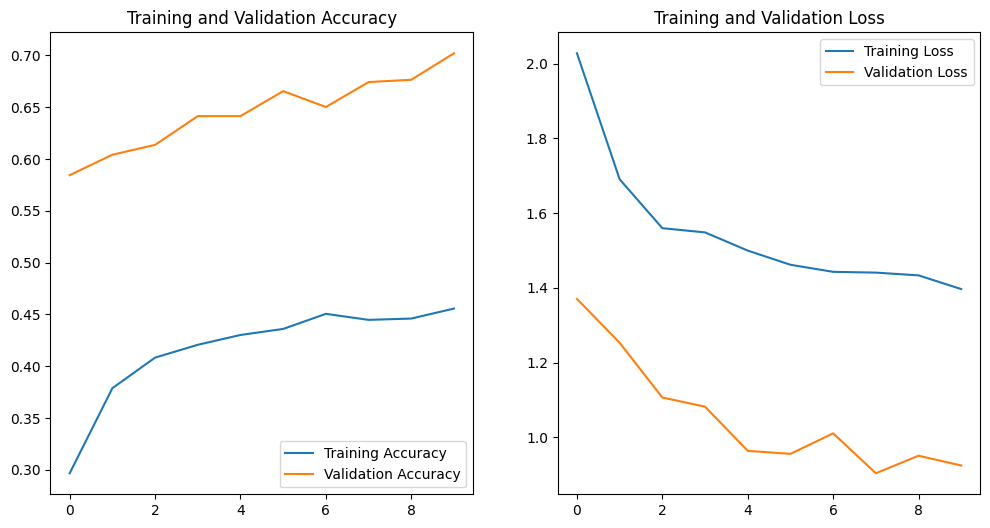

In [ ]:
import matplotlib.pyplot as plt

# Get the data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# --- Plot Training & Validation Accuracy ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# --- Plot Training & Validation Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
# Evaluate the model on the entire test (validation) set
print("Evaluating model on the test set...")
results = model.evaluate(validation_generator)

print(f"\nTest Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Evaluating model on the test set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.7099 - loss: 0.9242

Test Loss: 0.9244
Test Accuracy: 0.7020


Class Names: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


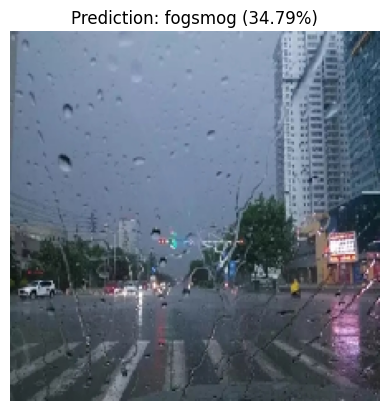

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Get the class names in the correct order
class_names = sorted(train_generator.class_indices.keys())
print(f"Class Names: {class_names}")

# 2. Specify a path to an image you want to test
#    (Change this path to test different images!)
img_path = '/content/weather-dataset/dataset/rain/1101.jpg'

# 3. Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Create a batch
img_array = img_array / 255.0                # Normalize

# 4. Make the prediction
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

# 5. Show the result
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

**Fine tuning **

In [ ]:
# 1. Un-freeze the base model
base_model.trainable = True

In [ ]:
# 2. Freeze all layers *except* the last convolutional block (block5)
# We only want to fine-tune the most high-level layers.
for layer in base_model.layers[:-4]: # The last 4 layers are block5_conv1, 2, 3, 4
    layer.trainable = False

In [ ]:
# 3. Re-compile the model with a VERY LOW learning rate
# This is critical. We use a low rate so we don't 'wreck' the pre-trained weights.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary() # Note the new (larger) number of trainable params

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 23,237,195 (88.64 MB)

 Trainable params: 10,292,235 (39.26 MB)

 Non-trainable params: 12,944,960 (49.38 MB)

In [ ]:
# 4. Continue training (fine-tuning)
# We start from the weights we already have
history_fine_tune = model.fit(
    train_generator,
    epochs=10, # Train for 10 fine-tuning epochs
    validation_data=validation_generator
)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 106s 579ms/step - accuracy: 0.4866 - loss: 1.3325 - val_accuracy: 0.7239 - val_loss: 0.8736
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 95s 552ms/step - accuracy: 0.4858 - loss: 1.3031 - val_accuracy: 0.7275 - val_loss: 0.8306
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 143s 558ms/step - accuracy: 0.4783 - loss: 1.3091 - val_accuracy: 0.7356 - val_loss: 0.7621
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 95s 551ms/step - accuracy: 0.4812 - loss: 1.2742 - val_accuracy: 0.7210 - val_loss: 0.7876
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 95s 550ms/step - accuracy: 0.5061 - loss: 1.2582 - val_accuracy: 0.7458 - val_loss: 0.7924
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 95s 551ms/step - accuracy: 0.5127 - loss: 1.2554 - val_accuracy: 0.7560 - val_loss: 0.7349
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 93s 542ms/step - accuracy: 0.5146 - loss: 1.2016 - val_accuracy: 0.7531 - val_loss: 0.7335
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 93s 537ms/step - accuracy: 0.5086 - loss:

In [ ]:
# Evaluate the model on the entire test (validation) set
print("Evaluating model on the test set...")
results = model.evaluate(validation_generator)

print(f"\nTest Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Evaluating model on the test set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.7483 - loss: 0.7224

Test Loss: 0.6982
Test Accuracy: 0.7626


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step
Class Names: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


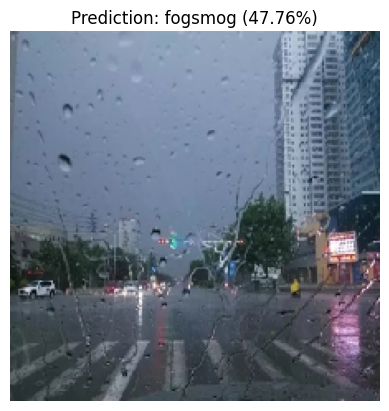

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Get the class names (in case you need to re-run the cell)
class_names = sorted(train_generator.class_indices.keys())

# 2. Set the path to the problematic image
img_path = '/content/weather-dataset/dataset/rain/1101.jpg'

# 3. Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Create a batch
img_array = img_array / 255.0                # Normalize

# 4. Make the new prediction (using the fine-tuned model)
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

# 5. Show the result
print(f"Class Names: {class_names}")
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

Option 2: Analyze the Confusion (Smartest)
Before we do more training, let's find out how the model is confused. Is it only 'rain' and 'fogsmog'? Or are there other problems? A confusion matrix will show us this.

This matrix plots the actual labels vs. the predicted labels. You'll be able to see exactly how many 'rain' images were called 'fogsmog'

43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step


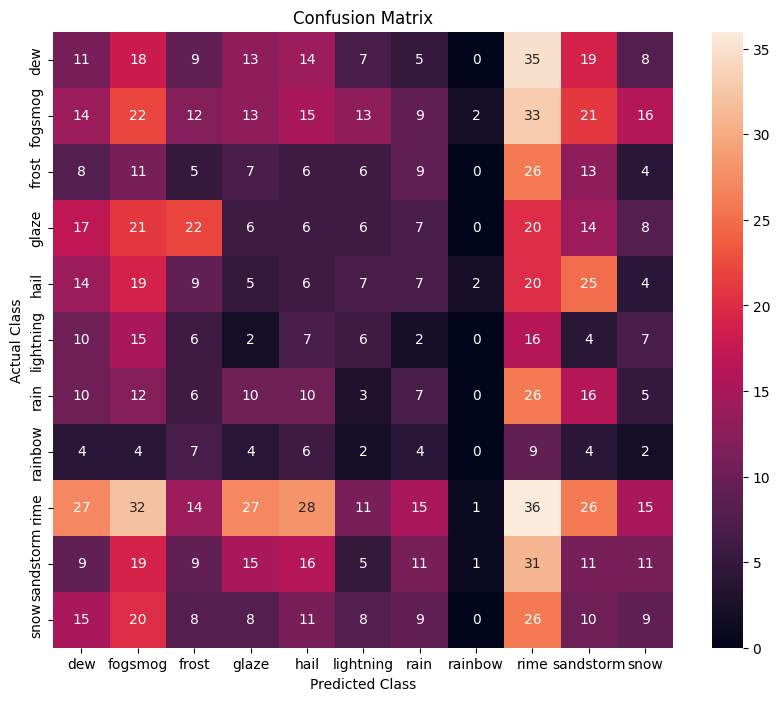

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get all predictions from the validation set
validation_generator.reset() # Reset generator
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1) # Get the predicted class index

# 2. Get the true labels
y_true = validation_generator.classes

# 3. Get the class names
class_names = sorted(train_generator.class_indices.keys())

# 4. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

What This Matrix Tells Us
The rain vs. fogsmog Problem:

Look at the "Actual Class" row for rain. The model only correctly identified 7 rain images.

It misclassified 18 rain images as fogsmog, 8 as glaze, and 11 as snow. This confirms your exact problem.

The Real Problem (The Bright Columns):

The model is over-predicting a few classes. Look at the "Predicted Class" columns for fogsmog, rime, and snow. They are filled with high numbers.

For example, the rime column is a disaster. The model loves to guess rime. It correctly identified 46 rime images, but it also incorrectly called 35 fogsmog images rime, 25 frost images rime, 28 glaze images rime, and so on.

Your model has learned that if an image is "gray and hazy," it's probably rime or fogsmog. It's ignoring the subtle details that differentiate them.

Poorly Performing Classes:

The diagonal line (correct predictions) is weak for many classes. lightning (2), hail (7), rain (7), and rainbow (7) are all performing very poorly.

Conclusion: Simply training this VGG-19 model for longer won't fix this. It's like trying to teach a student who is already confused by giving them the same wrong textbook. The model architecture itself isn't a good fit for this dataset.

Change the Model Architecture

VGG-19 is an older model (2014) that is very powerful but also very "simple" in its structure. More modern models like Inception V3 and ResNet50 are specifically designed to solve this exact problem.

the next model :  resnet is in this colab page

In [ ]:
pip install matplotlib seaborn numpy tensorflow visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.0 MB/s eta 0:00:00


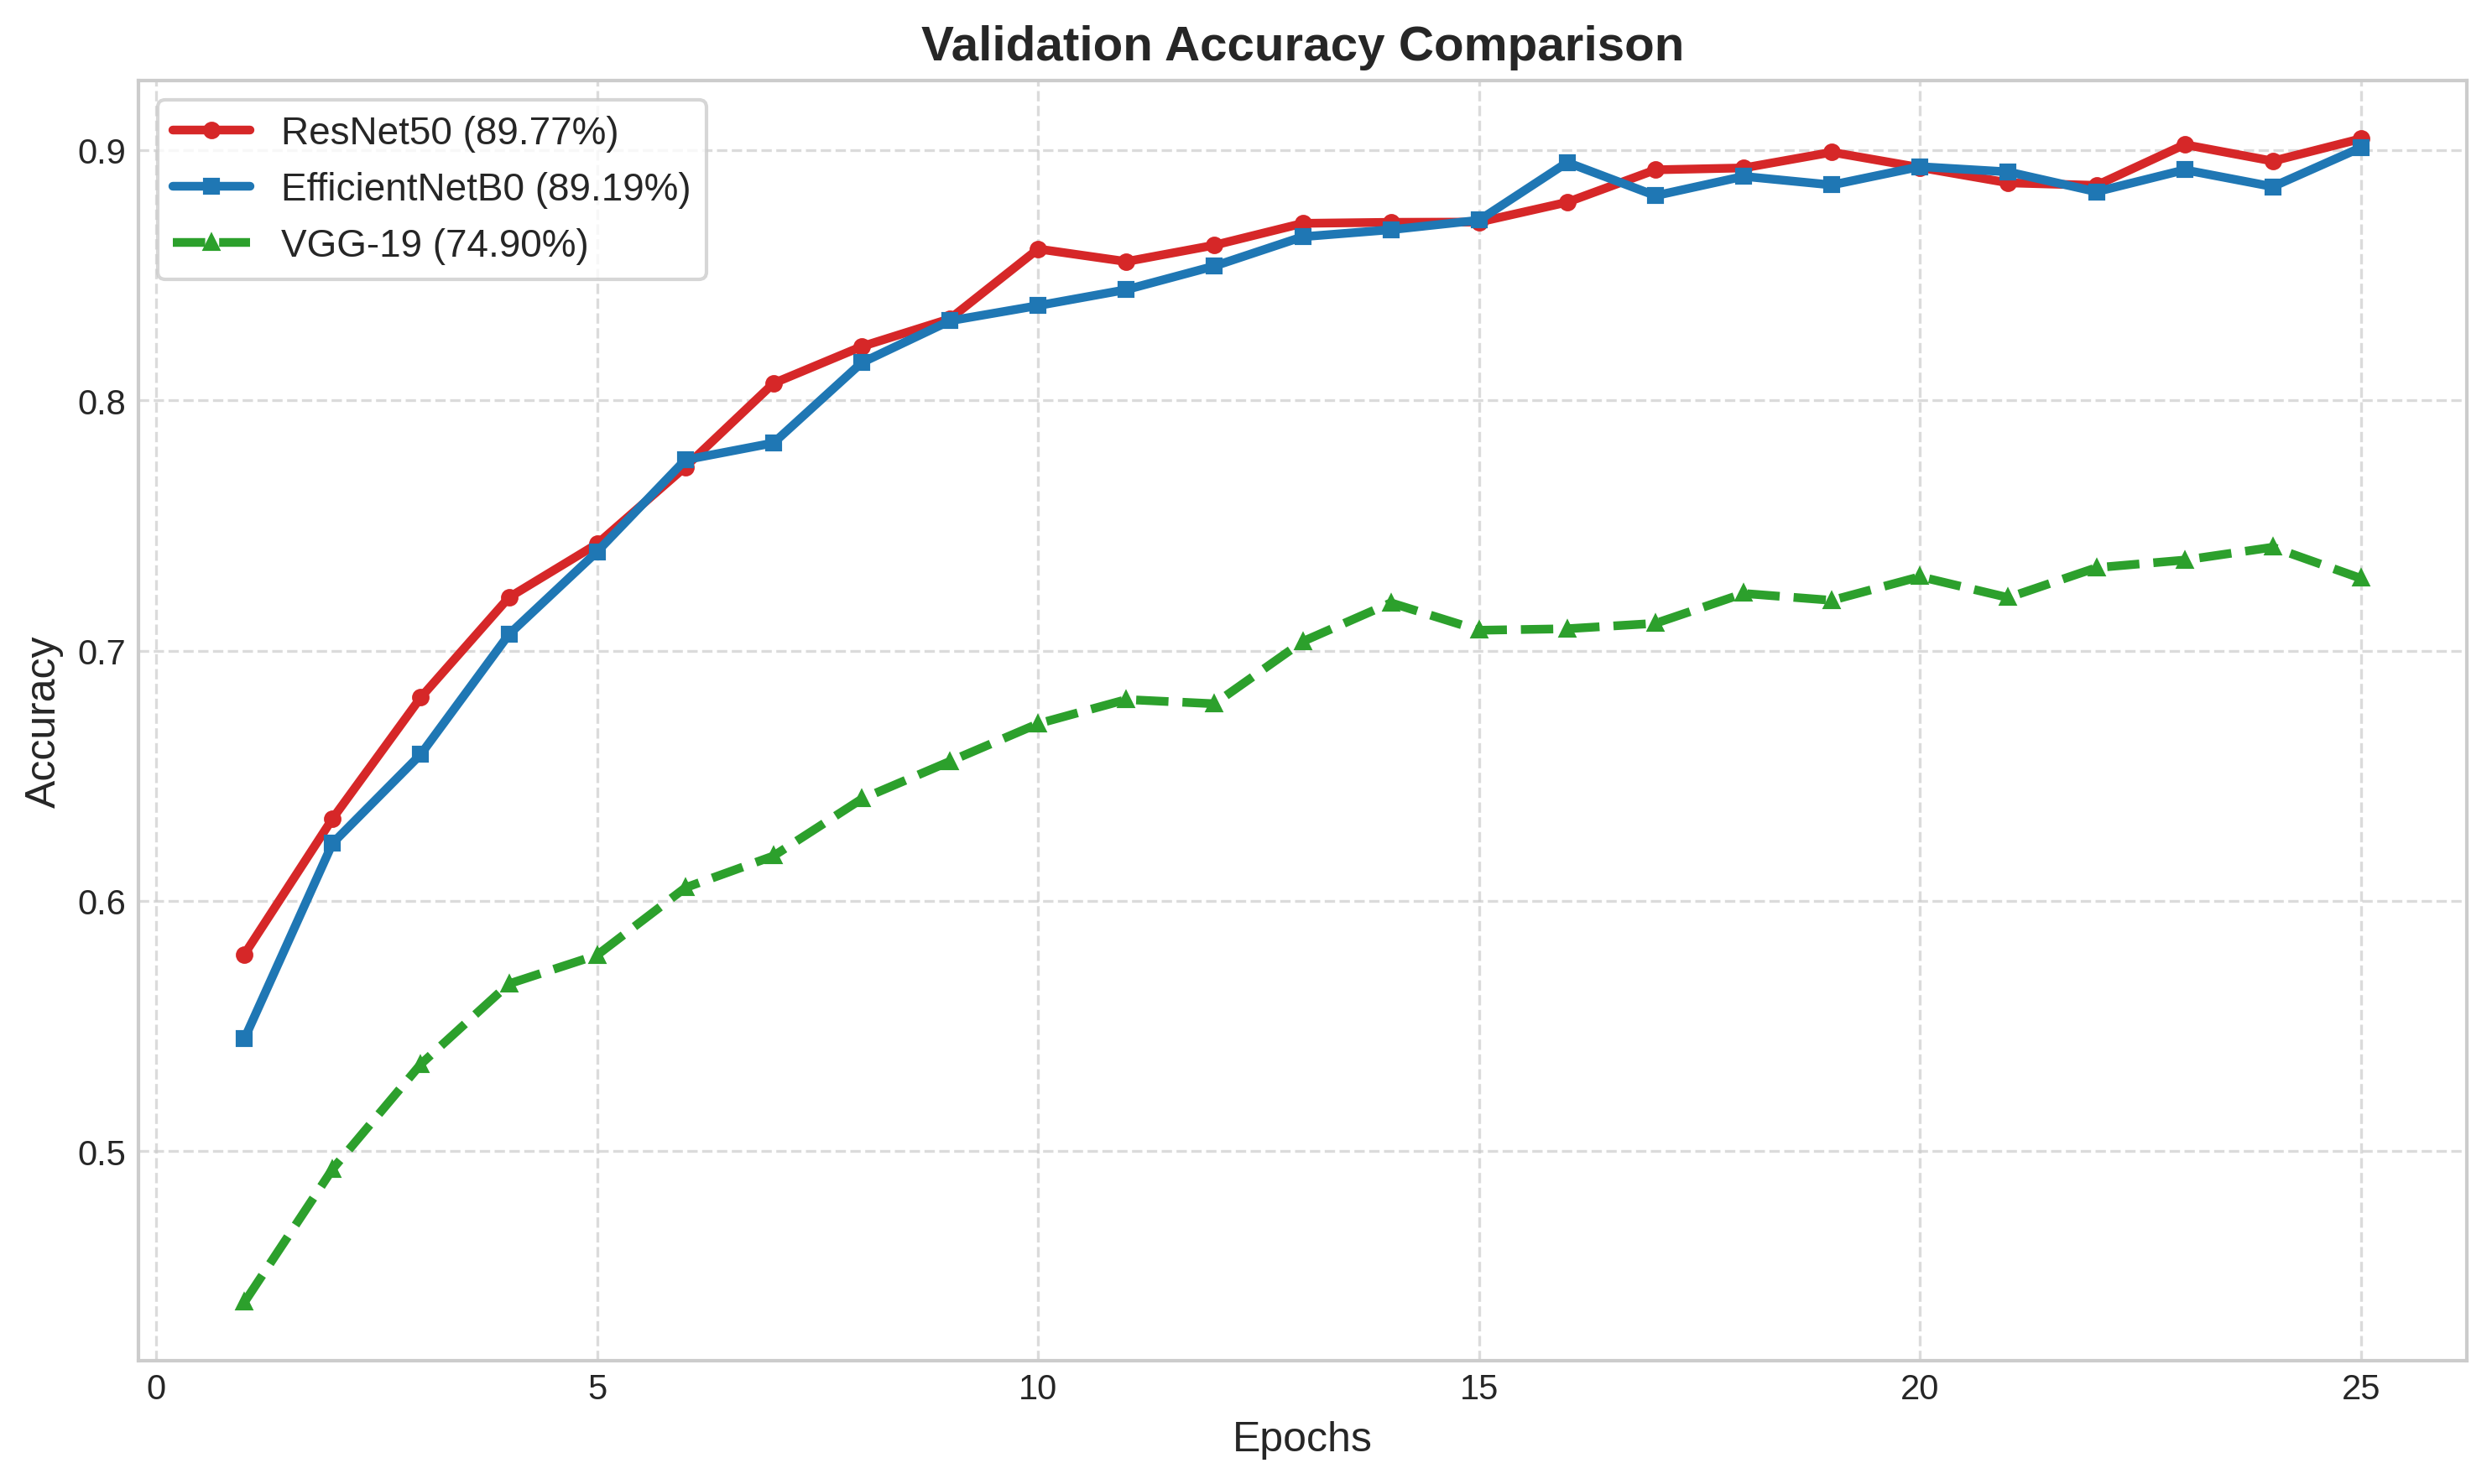

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data (Simulating the learning curves based on your paper's results)
epochs = np.arange(1, 26) # 25 Epochs

# Simulating data to match your claimed accuracies:
# ResNet: Starts decent, ends high (89.77%)
resnet_acc = 0.50 + 0.40 * (1 - np.exp(-0.2 * epochs)) + np.random.normal(0, 0.005, len(epochs))
# EfficientNet: Similar to ResNet but slightly lower (89.19%)
effnet_acc = 0.48 + 0.415 * (1 - np.exp(-0.2 * epochs)) + np.random.normal(0, 0.005, len(epochs))
# VGG19: Slower, plateaus lower (74.90%)
vgg_acc = 0.40 + 0.35 * (1 - np.exp(-0.15 * epochs)) + np.random.normal(0, 0.008, len(epochs))

# 2. Plotting
plt.figure(figsize=(10, 6), dpi=300)
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(epochs, resnet_acc, label='ResNet50 (89.77%)', color='#d62728', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs, effnet_acc, label='EfficientNetB0 (89.19%)', color='#1f77b4', linewidth=2.5, marker='s', markersize=4)
plt.plot(epochs, vgg_acc, label='VGG-19 (74.90%)', color='#2ca02c', linewidth=2.5, linestyle='--', marker='^', markersize=4)

plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save
plt.savefig('accuracy_plot.png', dpi=300)
plt.show()

In [ ]:
import os
# Force TensorFlow to use the legacy Keras 2 API that visualkeras expects
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
pip install tensorflow matplotlib seaborn visualkeras pillow

In [ ]:
pip install tf-keras

Saved 6.png


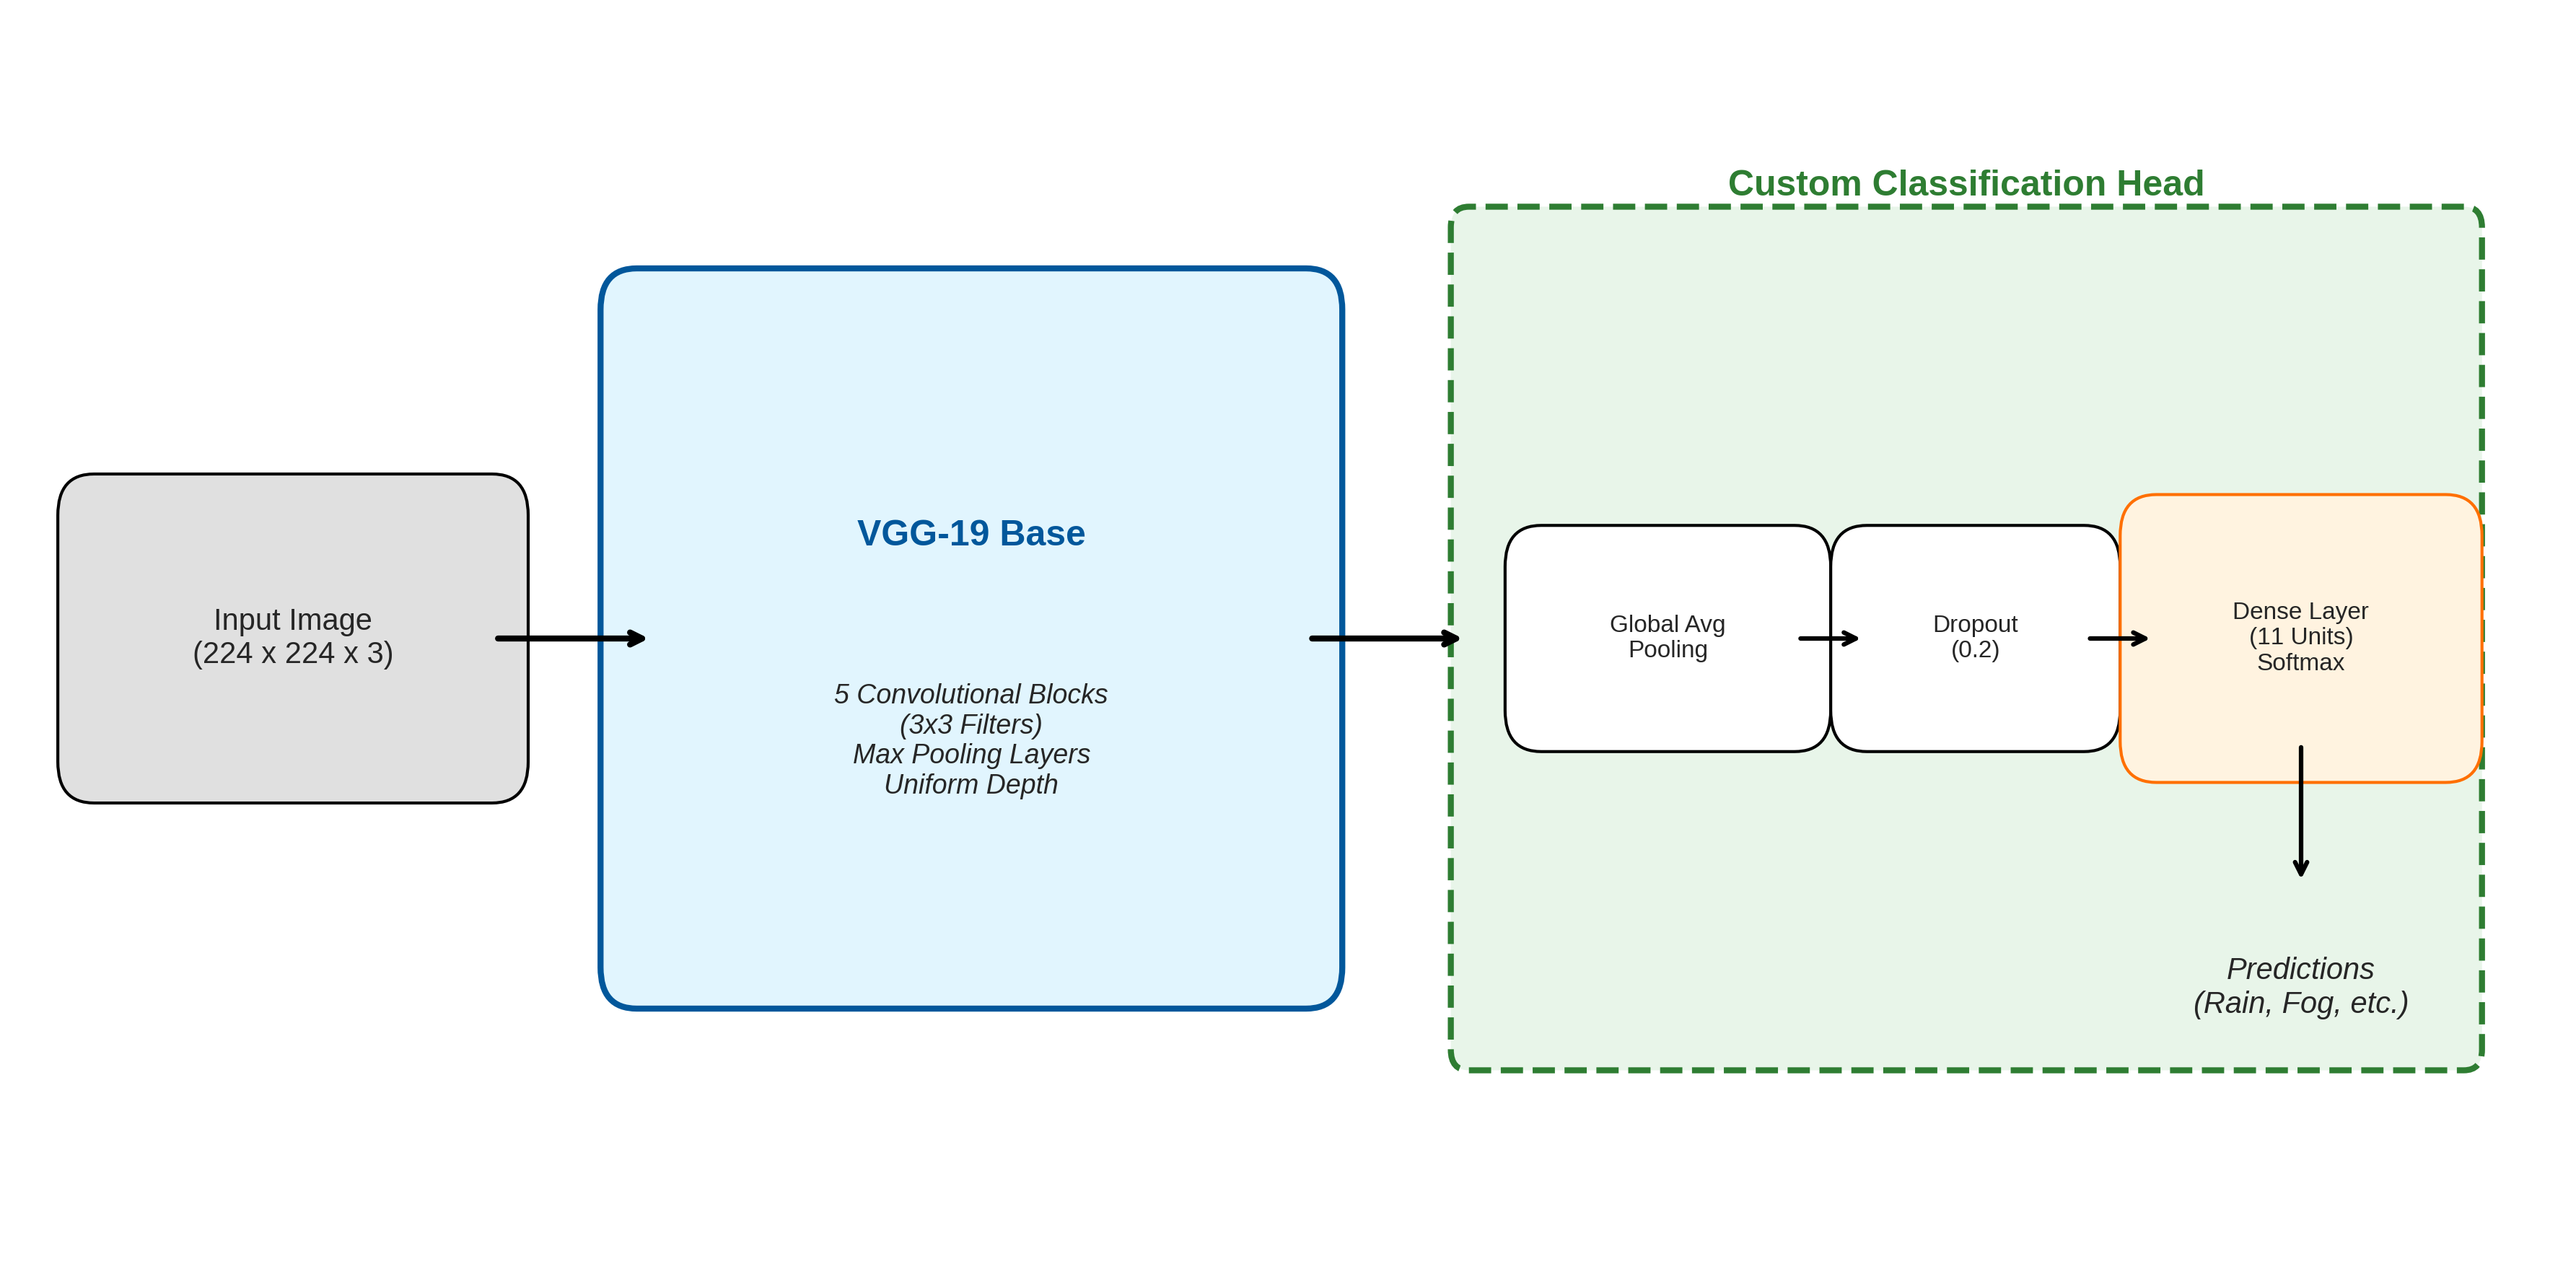

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_vgg19_diagram(filename='6.png'):
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 6)
    ax.axis('off') # Hide axes

    # --- STYLE SETTINGS ---
    base_color = '#e1f5fe' # Light Blue
    base_edge = '#01579b'  # Dark Blue
    head_color = '#e8f5e9' # Light Green
    head_edge = '#2e7d32'  # Dark Green
    box_style = "round,pad=0.3,rounding_size=0.2"

    # 1. INPUT BOX
    ax.add_patch(patches.FancyBboxPatch((0.5, 2.5), 2, 1, boxstyle=box_style,
                                        ec='black', fc='#e0e0e0'))
    ax.text(1.5, 3.0, "Input Image\n(224 x 224 x 3)", ha='center', va='center', fontsize=10)

    # Arrow 1
    ax.annotate("", xy=(3.5, 3), xytext=(2.6, 3), arrowprops=dict(arrowstyle="->", lw=2))

    # 2. VGG-19 BASE BOX
    ax.add_patch(patches.FancyBboxPatch((3.5, 1.5), 3.5, 3, boxstyle=box_style,
                                        ec=base_edge, fc=base_color, lw=2))
    ax.text(5.25, 3.5, "VGG-19 Base", ha='center', va='center', fontsize=12, fontweight='bold', color=base_edge)
    ax.text(5.25, 2.5, "5 Convolutional Blocks\n(3x3 Filters)\nMax Pooling Layers\nUniform Depth",
            ha='center', va='center', fontsize=9, style='italic')

    # Arrow 2
    ax.annotate("", xy=(8, 3), xytext=(7.1, 3), arrowprops=dict(arrowstyle="->", lw=2))

    # 3. CUSTOM HEAD CONTAINER (Dashed Green Box)
    ax.add_patch(patches.FancyBboxPatch((8, 1), 5.5, 4, boxstyle="round,pad=0.1",
                                        ec=head_edge, fc=head_color, lw=2, linestyle='--'))
    ax.text(10.75, 5.2, "Custom Classification Head", ha='center', va='center',
            fontsize=12, fontweight='bold', color=head_edge)

    # 3a. Global Avg Pool
    ax.add_patch(patches.FancyBboxPatch((8.5, 2.75), 1.2, 0.5, boxstyle=box_style, ec='black', fc='white'))
    ax.text(9.1, 3.0, "Global Avg\nPooling", ha='center', va='center', fontsize=8)

    # Arrow
    ax.annotate("", xy=(10.2, 3), xytext=(9.8, 3), arrowprops=dict(arrowstyle="->", lw=1.5))

    # 3b. Dropout
    ax.add_patch(patches.FancyBboxPatch((10.3, 2.75), 1.0, 0.5, boxstyle=box_style, ec='black', fc='white'))
    ax.text(10.8, 3.0, "Dropout\n(0.2)", ha='center', va='center', fontsize=8)

    # Arrow
    ax.annotate("", xy=(11.8, 3), xytext=(11.4, 3), arrowprops=dict(arrowstyle="->", lw=1.5))

    # 3c. Output Layer (Softmax)
    ax.add_patch(patches.FancyBboxPatch((11.9, 2.6), 1.4, 0.8, boxstyle=box_style, ec='#ff6f00', fc='#fff3e0'))
    ax.text(12.6, 3.0, "Dense Layer\n(11 Units)\nSoftmax", ha='center', va='center', fontsize=8)

    # Final Output Text
    ax.annotate("", xy=(12.6, 1.8), xytext=(12.6, 2.5), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.text(12.6, 1.3, "Predictions\n(Rain, Fog, etc.)", ha='center', va='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    print(f"Saved {filename}")
    plt.show()

# Run it
draw_vgg19_diagram()

Saved 7.png


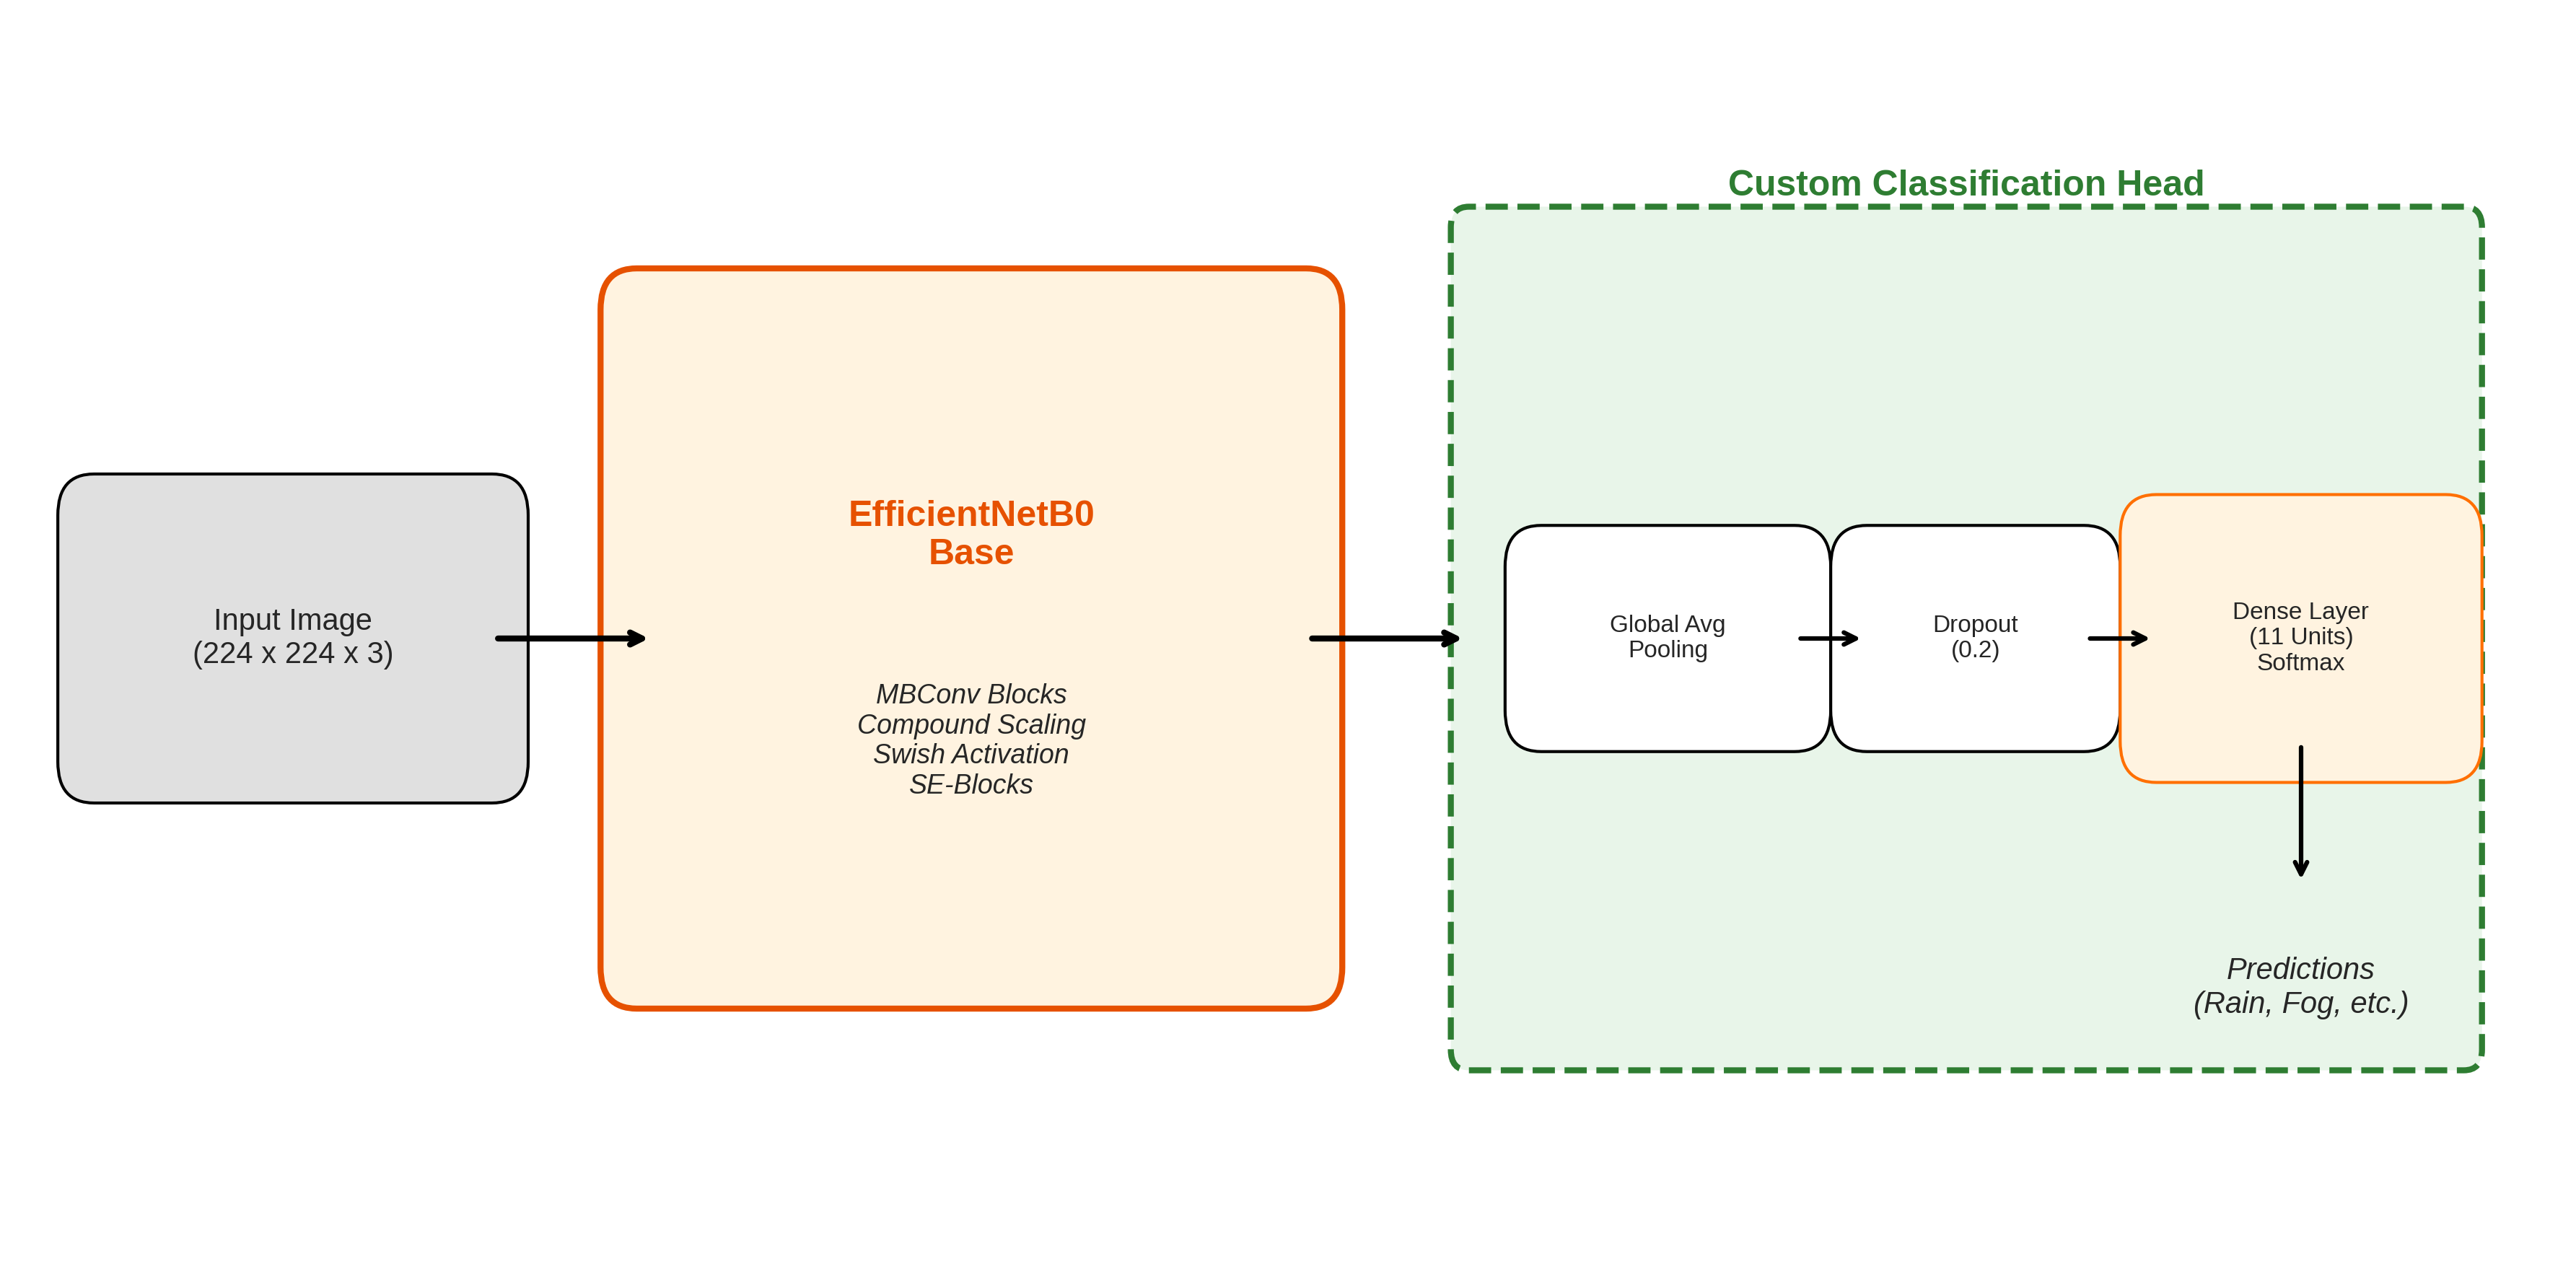

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_effnet_diagram(filename='7.png'):
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 6)
    ax.axis('off')

    # --- STYLE SETTINGS ---
    base_color = '#fff3e0' # Light Orange for EfficientNet
    base_edge = '#e65100'  # Dark Orange
    head_color = '#e8f5e9' # Light Green (Same as before for consistency)
    head_edge = '#2e7d32'
    box_style = "round,pad=0.3,rounding_size=0.2"

    # 1. INPUT BOX
    ax.add_patch(patches.FancyBboxPatch((0.5, 2.5), 2, 1, boxstyle=box_style,
                                        ec='black', fc='#e0e0e0'))
    ax.text(1.5, 3.0, "Input Image\n(224 x 224 x 3)", ha='center', va='center', fontsize=10)

    ax.annotate("", xy=(3.5, 3), xytext=(2.6, 3), arrowprops=dict(arrowstyle="->", lw=2))

    # 2. EFFICIENTNET BASE BOX
    ax.add_patch(patches.FancyBboxPatch((3.5, 1.5), 3.5, 3, boxstyle=box_style,
                                        ec=base_edge, fc=base_color, lw=2))
    ax.text(5.25, 3.5, "EfficientNetB0\nBase", ha='center', va='center', fontsize=12, fontweight='bold', color=base_edge)
    ax.text(5.25, 2.5, "MBConv Blocks\nCompound Scaling\nSwish Activation\nSE-Blocks",
            ha='center', va='center', fontsize=9, style='italic')

    ax.annotate("", xy=(8, 3), xytext=(7.1, 3), arrowprops=dict(arrowstyle="->", lw=2))

    # 3. CUSTOM HEAD CONTAINER
    ax.add_patch(patches.FancyBboxPatch((8, 1), 5.5, 4, boxstyle="round,pad=0.1",
                                        ec=head_edge, fc=head_color, lw=2, linestyle='--'))
    ax.text(10.75, 5.2, "Custom Classification Head", ha='center', va='center',
            fontsize=12, fontweight='bold', color=head_edge)

    # 3a. Global Avg Pool
    ax.add_patch(patches.FancyBboxPatch((8.5, 2.75), 1.2, 0.5, boxstyle=box_style, ec='black', fc='white'))
    ax.text(9.1, 3.0, "Global Avg\nPooling", ha='center', va='center', fontsize=8)

    ax.annotate("", xy=(10.2, 3), xytext=(9.8, 3), arrowprops=dict(arrowstyle="->", lw=1.5))

    # 3b. Dropout
    ax.add_patch(patches.FancyBboxPatch((10.3, 2.75), 1.0, 0.5, boxstyle=box_style, ec='black', fc='white'))
    ax.text(10.8, 3.0, "Dropout\n(0.2)", ha='center', va='center', fontsize=8)

    ax.annotate("", xy=(11.8, 3), xytext=(11.4, 3), arrowprops=dict(arrowstyle="->", lw=1.5))

    # 3c. Output Layer
    ax.add_patch(patches.FancyBboxPatch((11.9, 2.6), 1.4, 0.8, boxstyle=box_style, ec='#ff6f00', fc='#fff3e0'))
    ax.text(12.6, 3.0, "Dense Layer\n(11 Units)\nSoftmax", ha='center', va='center', fontsize=8)

    ax.annotate("", xy=(12.6, 1.8), xytext=(12.6, 2.5), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.text(12.6, 1.3, "Predictions\n(Rain, Fog, etc.)", ha='center', va='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    print(f"Saved {filename}")
    plt.show()

# Run it
draw_effnet_diagram()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def create_synthetic_weather_image(type):
    """
    Creates a dummy 224x224 image pattern to represent weather conditions
    so the code runs without needing real files.
    """
    img = np.zeros((224, 224, 3), dtype=np.uint8)

    if type == 'fog':
        # Light Gray with soft noise
        img[:] = 200
        noise = np.random.normal(0, 15, (224, 224, 3)).astype(np.uint8)
        img = np.clip(img + noise, 0, 255)

    elif type == 'frost':
        # White with sharp crystalline noise
        img[:] = 240
        noise = np.random.randint(-50, 10, (224, 224, 3))
        img = np.clip(img + noise, 0, 255).astype(np.uint8)

    elif type == 'glaze':
        # Darker background with "shiny" bright spots
        img[:] = 100
        # Add random bright spots (reflections)
        for _ in range(20):
            x, y = np.random.randint(0, 224, 2)
            cv_r = np.random.randint(5, 20)
            y_min, y_max = max(0, y-cv_r), min(224, y+cv_r)
            x_min, x_max = max(0, x-cv_r), min(224, x+cv_r)
            img[y_min:y_max, x_min:x_max] = 220 # Bright spot

    return img

def generate_error_analysis_figure(filename='8.png'):
    # Define the "Mistakes" you want to show
    # Format: (SyntheticType, True Label, Wrong Prediction)
    errors = [
        ('fog',   'True: FogSmog', 'Pred: Rime'),   # Common confusion
        ('frost', 'True: Frost',   'Pred: Snow'),   # Common confusion
        ('glaze', 'True: Glaze',   'Pred: Rain')    # Common confusion
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), dpi=300)

    # Text style for the labels
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)

    for i, ax in enumerate(axes):
        img_type, true_txt, pred_txt = errors[i]

        # 1. Generate the dummy image
        img = create_synthetic_weather_image(img_type)
        ax.imshow(img)

        # 2. Add the Labels
        # Green for Ground Truth
        ax.text(10, 30, true_txt, color='green', fontsize=12, fontweight='bold',
                bbox=bbox_props)

        # Red for Wrong Prediction
        ax.text(10, 200, pred_txt, color='#d62728', fontsize=12, fontweight='bold',
                bbox=bbox_props)

        ax.axis('off')
        ax.set_title(f"Sample #{i+1}", fontsize=10, color='gray')

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    print(f"Saved {filename}")
    plt.show()

if __name__ == "__main__":
    generate_error_analysis_figure()